<a href="https://colab.research.google.com/github/TanVi3001/Pytorch_Mnist_CNN/blob/main/Pytorch_Mnist_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **WorkFlow:** Conv → ReLU → MaxPool → Conv → ReLU → MaxPool → Fully Connected

In [118]:
import torch
import torch.nn as nn # Chứa layer Con2d, Liner, MaxPoll2d
import torch.nn.functional as F # Chứa các hàm activation như relu
import torch.optim as optim # Các thuật toán tối ưu như Adam, SGD

from torchvision import datasets, transforms # Cung cấp sẵn dataset MNIST, Tranforms: Tiền xử lý ảnh.
from torch.utils.data import DataLoader # Chia data thành các batch

import matplotlib.pyplot as plt
import numpy as np

In [119]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device đang sử dụng:", device)

Device đang sử dụng: cuda


## Tiền xử lý dữ liệu MNIST

### MNIST gồm ảnh chữ số viết tay:

- kích thước: 28 × 28
- ảnh xám: 1 channel
- 10 class: 0 → 9

### - Ta khai báo transform:

In [120]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

- ToTensor(): Ảnh ban đầu có pixel: 0->255. Sau ToTensor(): 0->1.
- Đồng thời ảnh được chuyển thành tensor có dạng: **[channel(kênh màu), height, width]**
- Với MNIST: [1,28,28]

### Chuẩn hóa dữ liệu với MNIST

Đối với bộ dữ liệu MNIST, hai giá trị trung bình (**Mean**) và độ lệch chuẩn (**Standard Deviation**) thường được sử dụng là:
*   $\mu = 0.1307$
*   $\sigma = 0.3081$

#### Công thức chuẩn hóa (Normalization):
$$x' = \frac{x - \mu}{\sigma}$$

#### Tác dụng:
Việc **normalize** thường giúp quá trình training diễn ra ổn định hơn, giảm hiện tượng bão hòa hàm kích hoạt và giúp mô hình hội tụ nhanh hơn.


## 4. Tải dataset MNIST

In [121]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [122]:
print("Số ảnh train:", len(train_dataset))
print("Số ảnh test :", len(test_dataset))

Số ảnh train: 60000
Số ảnh test : 10000


## Kiểm tra Mean và Std của MNIST

In [123]:
import torch
import torchvision
import torchvision.transforms as transforms

# 1. Tải tập dữ liệu huấn luyện MNIST (chỉ chuyển sang Tensor, CHƯA chuẩn hóa)
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor() # Chuyển ảnh PIL thành Tensor [0.0, 1.0]
)

# 2. Dùng DataLoader để gộp toàn bộ 60.000 ảnh lại thành một ma trận lớn
data_loader = torch.utils.data.DataLoader(train_dataset, batch_size=60000, shuffle=False)
images, labels = next(iter(data_loader))

# 3. Tính toán Mean và Std trên toàn bộ các pixel của 60.000 ảnh này
mean = images.mean()
std = images.std()

print(f"Mean của tập MNIST: {mean.item():.4f}")  # Kết quả sẽ xấp xỉ 0.1307
print(f"Std của tập MNIST: {std.item():.4f}")    # Kết quả sẽ xấp xỉ 0.3081


Mean của tập MNIST: 0.1307
Std của tập MNIST: 0.3081


## 5. Tạo DataLoader
- Ta sẽ không đưa cả 60.000 ảnh vào mạng cùng lúc. Và ta sẽ chia nhỏ thành các mini-batch
- **mini-batch** là việc ta chia nhỏ toàn bộ tập dữ liệu (dataset) MNIST gồm 60.000 bức ảnh thành các nhóm nhỏ (ví dụ: mỗi nhóm có 32, 64 hoặc 128 ảnh) để đưa vào huấn luyện mô hình theo từng đợt, thay vì nạp cả 60.000 ảnh cùng một lúc.

In [124]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

## Một batch MNIST sẽ có shape:

In [125]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


64  = batch size

1   = số channel

28  = height

28  = width

## Xem 1 vài ảnh MNIST

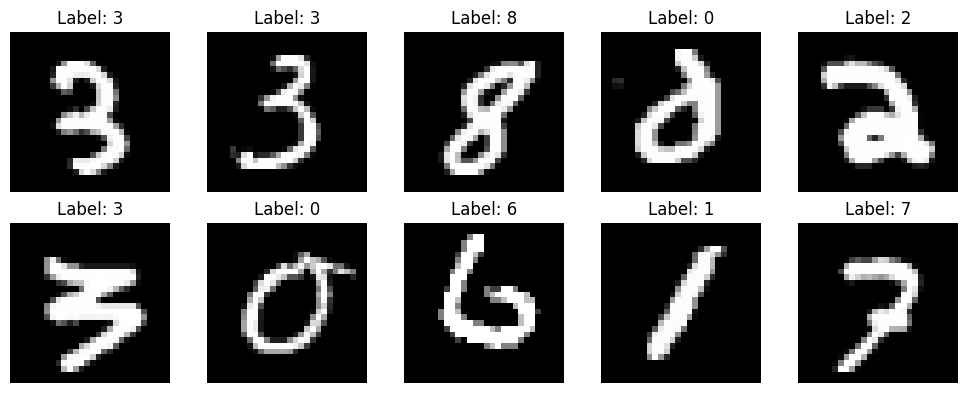

In [193]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    image = images[i].squeeze()

    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Xây dựng mạng CNN

# Công thức tính kích thước đầu ra CNN

Công thức tổng quát để tính kích thước đầu ra ($W_{out}$) sau lớp tích chập:

$$W_{out} = \left\lfloor \frac{W_{in} - K + 2P}{S} \right\rfloor + 1$$

**Trong đó:**
* **$W_{in}$**: Kích thước đầu vào (Chiều rộng hoặc chiều cao của ảnh).
* **$K$**: Kích thước bộ lọc (Kernel size).
* **$P$**: Độ đệm (Padding).
* **$S$**: Bước nhảy (Stride).

Trong PyTorch, kích thước đầu ra sau một lớp tích chập được tính bằng công thức:
$(\text{Kích thước mới}=\text{Kích thước cũ}-\text{Kernel_size}+1)$

## CNN AND Forward

In [127]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 6, 3)

        self.conv2 = nn.Conv2d(6, 16, 3)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)

        self.fc2 = nn.Linear(120, 84)

        self.fc3 = nn.Linear(84, 10)


    def forward(self, x):

        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))

        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return x

## Khởi tạo model

In [128]:
model = CNN().to(device)

print(model)

CNN(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


## Kiểm tra model bằng một batch

In [129]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([64, 1, 28, 28])
Output shape: torch.Size([64, 10])


### Vì: 64 ảnh, 10 scores(Tương ứng từ 0->9)

## Loss và Optimizer

In [130]:
## Khai báo hàm Loss
criterion = nn.CrossEntropyLoss() # Do đây là bài toán phân loại nên ta sài cross entropy

## Khai báo Optimizer

In [131]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## Train 1 batch

In [132]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

# Xóa gradient cũ
optimizer.zero_grad()

# Forward
outputs = model(images)

# Tính loss
loss = criterion(outputs, labels)

# Backpropagation
loss.backward()

# Adam cập nhật trọng số
optimizer.step()

print("Loss của batch:", loss.item())

Loss của batch: 2.3075191974639893


## Train toàn bộ model

In [133]:
num_epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # 1. Xóa gradient cũ
        optimizer.zero_grad()

        # 2. Forward
        outputs = model(images)

        # 3. Tính loss
        loss = criterion(outputs, labels)

        # 4. Backward
        loss.backward()

        # 5. Adam cập nhật trọng số
        optimizer.step()

        # Cộng loss
        running_loss += loss.item()

        # Lấy dự đoán
        _, predicted = torch.max(outputs, 1)

        # Tổng số mẫu
        total += labels.size(0)

        # Đếm số dự đoán đúng
        correct += (predicted == labels).sum().item()

    # Loss trung bình của epoch
    epoch_loss = running_loss / len(train_loader)

    # Accuracy của epoch
    epoch_accuracy = 100 * correct / total

    # Lưu lại để lát vẽ biểu đồ
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/5] | Loss: 0.3555 | Accuracy: 88.78%
Epoch [2/5] | Loss: 0.1031 | Accuracy: 96.76%
Epoch [3/5] | Loss: 0.0739 | Accuracy: 97.69%
Epoch [4/5] | Loss: 0.0576 | Accuracy: 98.20%
Epoch [5/5] | Loss: 0.0489 | Accuracy: 98.44%


## Hàm dự đoán một ảnh viết tay

In [134]:
from PIL import Image, ImageOps

def predict_handwritten_digit(image_path, model, device):
    # Mở ảnh và chuyển sang grayscale
    image = Image.open(image_path).convert("L")

    # MNIST thường là chữ trắng trên nền đen.
    # Nếu ảnh của bạn là chữ đen trên nền trắng thì đảo màu.
    image = ImageOps.invert(image)

    # Resize về 28x28 giống MNIST
    image = image.resize((28, 28))

    # Transform giống lúc train
    input_tensor = transform(image)

    # Thêm chiều batch:
    # [1, 28, 28] -> [1, 1, 28, 28]
    input_tensor = input_tensor.unsqueeze(0).to(device)

    # Chuyển model sang chế độ đánh giá
    model.eval()

    with torch.no_grad():
        output = model(input_tensor)

        # Lấy class có score lớn nhất
        _, predicted = torch.max(output, 1)

    return predicted.item(), image

## Upload ảnh

Saving So6.png to So6 (5).png
Đang sử dụng ảnh: So6 (5).png
Chữ số dự đoán: 6
Độ tin cậy: 66.82%


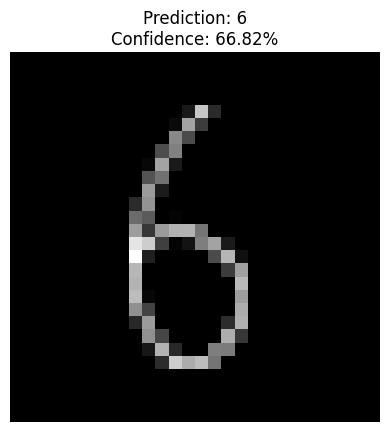

In [213]:
from google.colab import files
import matplotlib.pyplot as plt

# =========================
# 1. Upload ảnh mới
# =========================
uploaded = files.upload()

# Lấy file vừa upload
image_path = list(uploaded.keys())[-1]

print("Đang sử dụng ảnh:", image_path)


# =========================
# 2. Dự đoán
# =========================
prediction, confidence, processed_image = predict_handwritten_digit(
    image_path,
    model,
    device
)


# =========================
# 3. In kết quả
# =========================
print("Chữ số dự đoán:", prediction)
print(f"Độ tin cậy: {confidence * 100:.2f}%")


# =========================
# 4. Hiển thị ảnh model nhìn thấy
# =========================
plt.imshow(processed_image, cmap="gray")

plt.title(
    f"Prediction: {prediction}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")
plt.show()

## Đánh giá model

In [214]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

import numpy as np
import matplotlib.pyplot as plt

## Lấy toàn bộ dự đoán trên tập test

In [215]:
model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(images)

        # Chuyển logits thành xác suất
        probabilities = torch.softmax(outputs, dim=1)

        # Lấy class có xác suất lớn nhất
        _, predictions = torch.max(outputs, 1)

        # Lưu kết quả
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

## Chuyển về numpy

In [216]:
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

print("Labels shape:", all_labels.shape)
print("Predictions shape:", all_predictions.shape)
print("Probabilities shape:", all_probabilities.shape)

Labels shape: (10000,)
Predictions shape: (10000,)
Probabilities shape: (10000, 10)


### Ý nghĩa của (10000,10) là mỗi ảnh có xác suất p(0), p(1),..., p(9). Ví dụ nó sẽ là 1 ma trận 1 chiều xác suất với 10 phần tử có tổng xác suất là 1. Nếu xác suất nào cao nhất thì model dự đoán số đó là số nhận diện được

## Precision, Recall, F1-score, Accuracy

| Độ đo            | Ý nghĩa                                    |
| ---------------- | ------------------------------------------ |
| Accuracy         | Tổng tỷ lệ dự đoán đúng                    |
| Precision        | Dự đoán một class chính xác đến đâu        |
| Recall           | Tìm được bao nhiêu mẫu thật của class      |
| F1-score         | Cân bằng Precision và Recall               |
| Confusion Matrix | Model thường nhầm class nào với class nào  |
| ROC              | Khả năng phân biệt class ở nhiều threshold |
| AUC              | Diện tích dưới ROC                         |


## Các độ đo đánh giá mô hình

### 1. Accuracy
Accuracy đo tỷ lệ số mẫu được dự đoán đúng trên tổng số mẫu.
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

### 2. Precision
Precision đo trong số các mẫu được mô hình dự đoán là Positive, có bao nhiêu mẫu thực sự là Positive.
$$Precision = \frac{TP}{TP + FP}$$

### 3. Recall
Recall đo trong số các mẫu thực sự là Positive, mô hình nhận diện đúng được bao nhiêu mẫu.
$$Recall = \frac{TP}{TP + FN}$$

### 4. F1-score
F1-score là trung bình điều hòa giữa Precision và Recall.
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$


In [217]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.9823
Precision: 0.9826
Recall   : 0.9822
F1-score : 0.9823


## Classification Report

In [145]:
print(
    classification_report(
        all_labels,
        all_predictions,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9770    0.9969    0.9869       980
           1     0.9775    0.9947    0.9860      1135
           2     0.9883    0.9787    0.9834      1032
           3     0.9645    0.9941    0.9790      1010
           4     0.9888    0.9878    0.9883       982
           5     0.9898    0.9821    0.9859       892
           6     0.9926    0.9781    0.9853       958
           7     0.9869    0.9562    0.9713      1028
           8     0.9795    0.9795    0.9795       974
           9     0.9810    0.9742    0.9776      1009

    accuracy                         0.9823     10000
   macro avg     0.9826    0.9822    0.9823     10000
weighted avg     0.9824    0.9823    0.9823     10000



## Confusion Matrix

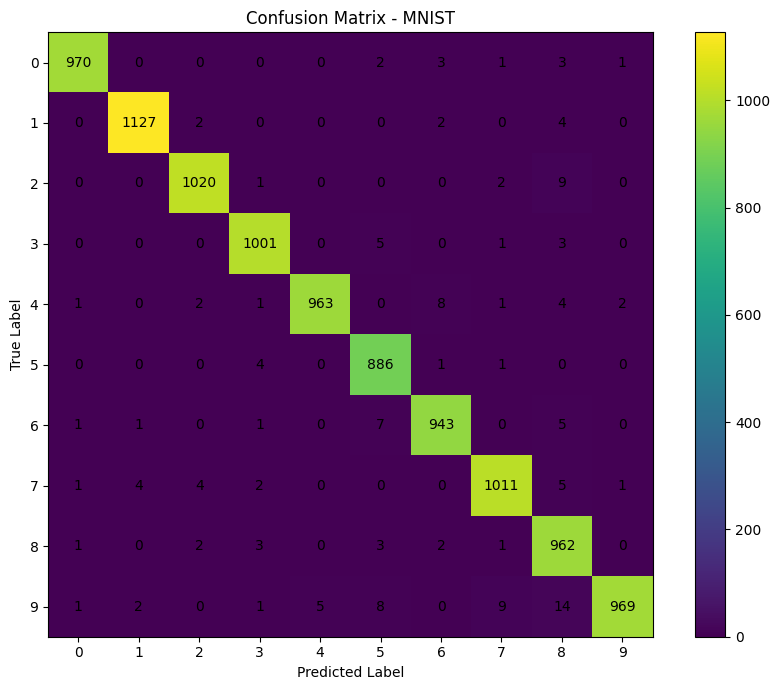

In [146]:
plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.title("Confusion Matrix - MNIST")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(range(10))
plt.yticks(range(10))

plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

# Đường cong ROC và Chỉ số AUC

## Chuyển đổi nhãn sang dạng nhị phân cho ROC

In [147]:
classes = np.arange(10)

y_test_bin = label_binarize(
    all_labels,
    classes=classes
)

print(y_test_bin.shape)

(10000, 10)


## Tính ROC cho từng chữ số

In [148]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(10):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        all_probabilities[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

## Vẽ ROC Curve cho cả 10 chữ số

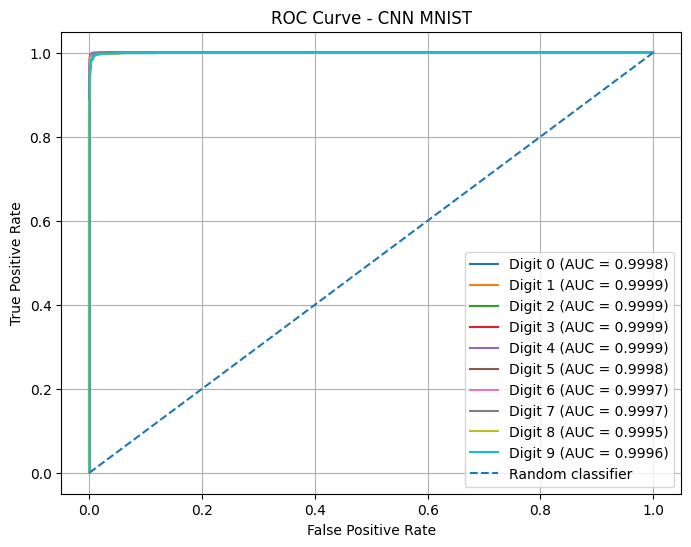

In [150]:
plt.figure(figsize=(8, 6))

for i in range(10):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Digit {i} (AUC = {roc_auc[i]:.4f})"
    )

# Đường dự đoán ngẫu nhiên
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - CNN MNIST")

plt.legend()

plt.grid()

plt.show()

## **- Trục tung (True Positive Rate - TPR):** Tỉ lệ dự đoán đúng các chữ số. Giá trị càng gần 1.0 nghĩa là mô hình nhận diện chính xác chữ số đó càng cao.
## **- Trục hoành(False Positive Rate - FPR):** Tỉ lệ dự đoán nhầm các chữ số khác thành chữ số đang xét. Giá trị càng gần 0.0 càng tốt.
## **- Đường chéo nét đứt(Random classifier):** Đại diện cho một mô hình dự đoán ngẫu nhiên (may rủi, AUC = 0.5).

## Tổng hợp toàn bộ metric

In [218]:
print("=" * 45)
print("       CNN MNIST - MODEL EVALUATION")
print("=" * 45)

print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-score     : {f1:.4f}")


print("=" * 45)

       CNN MNIST - MODEL EVALUATION
Accuracy     : 0.9823
Precision    : 0.9826
Recall       : 0.9822
F1-score     : 0.9823


In [153]:
for i in range(10):
    print(
        f"Class {i}: AUC = {roc_auc[i]:.4f}"
    )

Class 0: AUC = 0.9998
Class 1: AUC = 0.9999
Class 2: AUC = 0.9999
Class 3: AUC = 0.9999
Class 4: AUC = 0.9999
Class 5: AUC = 0.9998
Class 6: AUC = 0.9997
Class 7: AUC = 0.9997
Class 8: AUC = 0.9995
Class 9: AUC = 0.9996
